In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/MINI_Project_BATCH8/Datasets/Heart_Transplant_edited.csv',low_memory=False)

In [4]:
!ls /content/drive/MyDrive/MINI_Project_BATCH8/

 Datasets   Models   Organ_dup.zip   pickle_models  'Sources '


In [5]:
df.head()

,NUM_PREV_TX,GENDER,PGE_TCR,CEREB_VASC,IMPL_DEFIBRIL,DAYSWAIT_CHRON,END_STAT,END_HGT_CM_CALC,END_WGT_KG_CALC,REGION,...,citizen,payer,diabetes,medcondition,CITIZENDON,racedon,abo,cath,vol_quartile,365DaySurvival
0,0,M,False,False,False,3.0,2010,173.00,71.000,9,...,US citizen,Private insurance/Selfpay,NaN,ICU,citizen,white,AB,not done,4,True
1,0,M,False,False,True,137.0,2020,170.18,63.503,9,...,Non citizen,Medicaid,NaN,not hosp,citizen,Hispanic,O,normal,4,True
2,0,F,False,False,True,25.0,2020,162.56,68.039,9,...,US citizen,Private insurance/Selfpay,NaN,hosp,citizen,white,B,not done,4,True
3,0,M,False,False,True,287.0,2010,171.40,78.472,9,...,US citizen,Private insurance/Selfpay,NaN,ICU,citizen,Black/AA,O,not done,4,True
4,0,M,False,False,False,1101.0,2010,188.00,111.584,9,...,US citizen,Medicaid,NaN,hosp,citizen,Hispanic,O,not done,4,True


In [6]:
df.isna().sum()

,0
NUM_PREV_TX,0
GENDER,0
PGE_TCR,0
CEREB_VASC,479
IMPL_DEFIBRIL,696
...,...
racedon,0
abo,0
cath,0
vol_quartile,0


In [7]:
df.tail(12)

,NUM_PREV_TX,GENDER,PGE_TCR,CEREB_VASC,IMPL_DEFIBRIL,DAYSWAIT_CHRON,END_STAT,END_HGT_CM_CALC,END_WGT_KG_CALC,REGION,...,citizen,payer,diabetes,medcondition,CITIZENDON,racedon,abo,cath,vol_quartile,365DaySurvival
43082,0,M,False,False,True,14.0,2120,180.40,109.500,3,...,US citizen,Medicare,NaN,ICU,citizen,Black/AA,O,not done,1,True
43083,0,M,False,False,False,19.0,2150,178.00,103.240,3,...,US citizen,Medicare,Yes,not hosp,citizen,Black/AA,O,not done,1,False
43084,0,F,False,False,True,18.0,2140,167.64,69.400,3,...,US citizen,Private insurance/Selfpay,NaN,not hosp,citizen,white,B,not done,1,False
43085,0,M,False,False,True,12.0,2140,175.26,73.936,3,...,US citizen,Medicare,NaN,not hosp,citizen,white,A,abnormal,1,True
43086,0,M,False,False,False,7.0,2120,190.50,108.000,3,...,US citizen,Private insurance/Selfpay,NaN,ICU,citizen,white,A,normal,1,True
43087,0,M,False,False,True,8.0,2140,170.00,100.000,3,...,US citizen,Medicare,Yes,not hosp,non-citizen,white,A,not done,1,False
43088,0,M,False,False,True,439.0,2010,158.80,92.800,11,...,US citizen,Medicaid,NaN,hosp,citizen,white,O,not done,1,True
43089,0,M,False,False,False,77.0,2010,160.50,62.400,11,...,US citizen,Medicaid,NaN,ICU,citizen,white,O,not done,1,True
43090,0,M,False,False,False,381.0,2010,179.00,114.000,11,...,US citizen,Medicaid,NaN,not hosp,citizen,white,O,not done,1,True
43091,0,M,False,False,False,141.0,2140,157.50,49.600,4,...,US citizen,Private insurance/Selfpay,NaN,not hosp,citizen,Hispanic,A,not done,1,False


In [8]:
df = df[['AGE', 'AGE_DON','CREAT_TRR', 'CREAT_DON', 'diagnosis',
         'CODDON', 'BMI_CALC', 'BMI_DON_CALC', 'DAYSWAIT_CHRON', 'mcs', 'medcondition',
         'abo', 'ABOMAT', 'DISTANCE', 'HIST_MI', 'diabetes', 'TX_YEAR','365DaySurvival']]


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43094 entries, 0 to 43093
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AGE             43092 non-null  float64
 1   AGE_DON         43094 non-null  int64  
 2   CREAT_TRR       42756 non-null  float64
 3   CREAT_DON       43034 non-null  float64
 4   diagnosis       43094 non-null  object 
 5   CODDON          42871 non-null  object 
 6   BMI_CALC        43064 non-null  float64
 7   BMI_DON_CALC    43076 non-null  float64
 8   DAYSWAIT_CHRON  43091 non-null  float64
 9   mcs             43094 non-null  object 
 10  medcondition    43094 non-null  object 
 11  abo             43094 non-null  object 
 12  ABOMAT          43094 non-null  object 
 13  DISTANCE        43093 non-null  float64
 14  HIST_MI         42794 non-null  object 
 15  diabetes        11089 non-null  object 
 16  TX_YEAR         43094 non-null  int64  
 17  365DaySurvival  43094 non-null 

In [10]:


#To remove NUll values in numeric type values
df = df.fillna(df.median(numeric_only=True))

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43094 entries, 0 to 43093
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AGE             43094 non-null  float64
 1   AGE_DON         43094 non-null  int64  
 2   CREAT_TRR       43094 non-null  float64
 3   CREAT_DON       43094 non-null  float64
 4   diagnosis       43094 non-null  object 
 5   CODDON          42871 non-null  object 
 6   BMI_CALC        43094 non-null  float64
 7   BMI_DON_CALC    43094 non-null  float64
 8   DAYSWAIT_CHRON  43094 non-null  float64
 9   mcs             43094 non-null  object 
 10  medcondition    43094 non-null  object 
 11  abo             43094 non-null  object 
 12  ABOMAT          43094 non-null  object 
 13  DISTANCE        43094 non-null  float64
 14  HIST_MI         42794 non-null  object 
 15  diabetes        11089 non-null  object 
 16  TX_YEAR         43094 non-null  int64  
 17  365DaySurvival  43094 non-null 

In [12]:
#To remove Null values in Categorical type values
rem_null_cate = ['diagnosis','CODDON','mcs','medcondition','abo','ABOMAT','HIST_MI','diabetes','365DaySurvival']

for rem in rem_null_cate:
  df[rem] = df[rem].fillna(df[rem].mode()[0])



In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43094 entries, 0 to 43093
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AGE             43094 non-null  float64
 1   AGE_DON         43094 non-null  int64  
 2   CREAT_TRR       43094 non-null  float64
 3   CREAT_DON       43094 non-null  float64
 4   diagnosis       43094 non-null  object 
 5   CODDON          43094 non-null  object 
 6   BMI_CALC        43094 non-null  float64
 7   BMI_DON_CALC    43094 non-null  float64
 8   DAYSWAIT_CHRON  43094 non-null  float64
 9   mcs             43094 non-null  object 
 10  medcondition    43094 non-null  object 
 11  abo             43094 non-null  object 
 12  ABOMAT          43094 non-null  object 
 13  DISTANCE        43094 non-null  float64
 14  HIST_MI         43094 non-null  object 
 15  diabetes        43094 non-null  object 
 16  TX_YEAR         43094 non-null  int64  
 17  365DaySurvival  43094 non-null 

In [14]:
df['CODDON'].value_counts()

,count
CODDON,
Trauma,22381
IntracranHem/Stroke/Seiz,9745
Drug Intoxication,4762
Cardiovascular,3655
Anoxia/Asphyx,2186
Drowning,217
Natural Causes,148


In [15]:
df.isna().sum().sum()

np.int64(0)

In [16]:
#Duplicating the values of the cols

from sklearn.preprocessing import LabelEncoder
#For Ordinal Values
cat_cols = ['medcondition','ABOMAT']
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


#For nomial values
cat_cols = ['diagnosis', 'mcs','abo','CODDON','diabetes','HIST_MI']

df = pd.get_dummies(df, columns=cat_cols)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43094 entries, 0 to 43093
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   AGE                              43094 non-null  float64
 1   AGE_DON                          43094 non-null  int64  
 2   CREAT_TRR                        43094 non-null  float64
 3   CREAT_DON                        43094 non-null  float64
 4   BMI_CALC                         43094 non-null  float64
 5   BMI_DON_CALC                     43094 non-null  float64
 6   DAYSWAIT_CHRON                   43094 non-null  float64
 7   medcondition                     43094 non-null  int64  
 8   ABOMAT                           43094 non-null  int64  
 9   DISTANCE                         43094 non-null  float64
 10  TX_YEAR                          43094 non-null  int64  
 11  365DaySurvival                   43094 non-null  bool   
 12  diagnosis_CONGENIT

In [18]:
df.head(9)

,AGE,AGE_DON,CREAT_TRR,CREAT_DON,BMI_CALC,BMI_DON_CALC,DAYSWAIT_CHRON,medcondition,ABOMAT,DISTANCE,...,CODDON_Anoxia/Asphyx,CODDON_Cardiovascular,CODDON_Drowning,CODDON_Drug Intoxication,CODDON_IntracranHem/Stroke/Seiz,CODDON_Natural Causes,CODDON_Trauma,diabetes_Yes,HIST_MI_N,HIST_MI_Y
0,55.0,22,1.11,4.40,23.323418,33.798788,3.0,0,1,729.0,...,False,False,False,False,False,False,True,True,True,False
1,55.0,30,1.40,0.80,30.470522,28.822372,137.0,2,1,51.0,...,False,False,False,False,True,False,False,True,True,False
2,56.0,32,1.70,1.30,23.687385,18.990905,25.0,1,1,517.0,...,False,False,False,False,False,False,True,True,True,False
3,42.0,25,1.10,0.90,27.095359,20.830703,287.0,0,1,496.0,...,False,False,False,False,False,False,True,True,True,False
4,32.0,24,1.09,3.58,31.405613,30.387144,1101.0,1,1,4.0,...,False,False,False,True,False,False,False,True,True,False
5,64.0,37,0.82,0.53,23.896733,23.828125,326.0,2,1,17.0,...,False,False,False,False,True,False,False,True,True,False
6,22.0,14,0.70,0.70,21.468233,24.040864,21.0,0,1,215.0,...,False,False,False,False,False,False,True,True,True,False
7,65.0,20,1.77,1.64,25.864512,21.420408,2956.0,2,1,5.0,...,True,False,False,False,False,False,False,True,True,False
8,60.0,19,1.26,0.90,33.593120,30.583260,123.0,0,0,31.0,...,False,False,False,False,False,False,True,True,True,False


In [19]:

df['medcondition'].value_counts()

,count
medcondition,
2,21552
0,14477
1,7065


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43094 entries, 0 to 43093
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   AGE                              43094 non-null  float64
 1   AGE_DON                          43094 non-null  int64  
 2   CREAT_TRR                        43094 non-null  float64
 3   CREAT_DON                        43094 non-null  float64
 4   BMI_CALC                         43094 non-null  float64
 5   BMI_DON_CALC                     43094 non-null  float64
 6   DAYSWAIT_CHRON                   43094 non-null  float64
 7   medcondition                     43094 non-null  int64  
 8   ABOMAT                           43094 non-null  int64  
 9   DISTANCE                         43094 non-null  float64
 10  TX_YEAR                          43094 non-null  int64  
 11  365DaySurvival                   43094 non-null  bool   
 12  diagnosis_CONGENIT

#Training Model


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score
from imblearn.over_sampling import RandomOverSampler

In [22]:
X = df.drop(columns=['365DaySurvival'])
y = df['365DaySurvival']


print("Original dataset shape:", y.value_counts())

ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)


print("Resampled dataset shape:", y_resampled.value_counts())

Original dataset shape: 365DaySurvival
True     38242
False     4852
Name: count, dtype: int64
Resampled dataset shape: 365DaySurvival
True     38242
False    38242
Name: count, dtype: int64


In [23]:
from sklearn.ensemble import RandomForestClassifier

x_train_resampled, x_test_resampled, y_train_resampled, y_test_resampled = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=0)

rf_resampled = RandomForestClassifier(random_state=45)
rf_resampled.fit(x_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=45)

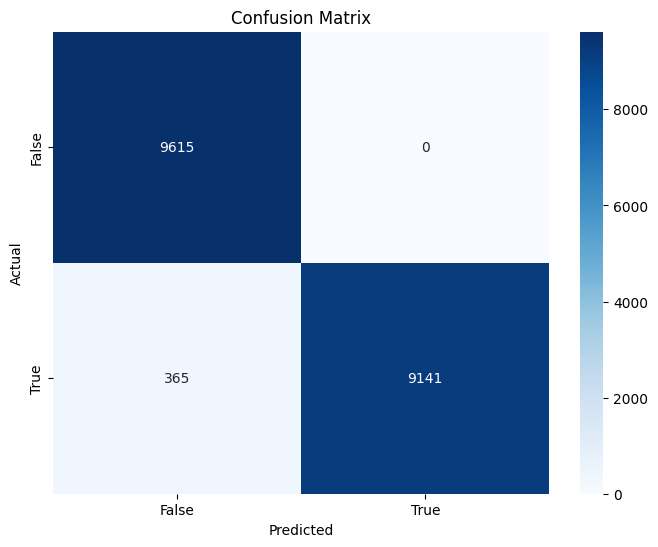

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_resampled = rf_resampled.predict(x_test_resampled)
cm = confusion_matrix(y_test_resampled, y_pred_resampled)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
y_pred_resampled = rf_resampled.predict(x_test_resampled)

print("Classification Report (Resampled Data):")
print(classification_report(y_test_resampled, y_pred_resampled))

y_prob_resampled = rf_resampled.predict_proba(x_test_resampled)[:, 1]
auc_score_resampled = roc_auc_score(y_test_resampled, y_prob_resampled)
print(f"AUC Score (Resampled Data): {auc_score_resampled}")

Classification Report (Resampled Data):
              precision    recall  f1-score   support

       False       0.96      1.00      0.98      9615
        True       1.00      0.96      0.98      9506

    accuracy                           0.98     19121
   macro avg       0.98      0.98      0.98     19121
weighted avg       0.98      0.98      0.98     19121

AUC Score (Resampled Data): 0.9999091960312118


#PICKLE MODEL

In [26]:
import pickle
filename = 'heart_transplant.sav'
pickle.dump(rf_resampled,open(filename,'wb'))
loaded_model = pickle.load(open('heart_transplant.sav','rb'))

In [27]:
input_data = (62	,17,	0.9,	1,	16.6498563,	22.70512354,	57,	2,	1,	941,	2009	,False	,False,	False	,True	,False,	False,	False,	False,	False,	False,	False,	False,	False	,False	,True	,False,	False,	False,	True,	False,	False	,False	,True	,False,	False,	False,	False	,True	,True	,False
)

np_array = np.asarray(input_data)
np_array_reshape = np_array.reshape(1,-1)
prediction_resampled = loaded_model.predict(np_array_reshape)
print(prediction_resampled)

if (prediction_resampled[0]==True):
  print("Matching")
else:
  print("Not Matching")

[False]
Not Matching


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [28]:
#df.to_excel('cleaned_heart_data.xlsx',index =False)

In [29]:
from importlib.metadata import version
print(version('scikit-learn'))

1.6.1
